# Extended depth-of-focus

In [1]:
import torch
import sys
import os
sys.path.append('../')
from DataType.ElectricField import ElectricField
from LightSource.Gaussian_beam import Guassian_beam
from LightSource.PlaneWave import PlaneWave
from Props.ASM_Prop import ASM_prop
from Props.RSC_Prop import RSC_prop
from Components.Thin_Lens import Thin_LensElement
from Components.Aperture import ApertureElement
from Components.QuantizedDOE import FixDOEElement
from utils.Helper_Functions import normalize, DOE_xyz_cordinates_Generator
from utils.units import *
import numpy as np
import scipy.io
import time
import torch.nn as nn
import torch.nn.functional as F
import random

In [32]:
c0 = 2.998e8

# measured plane wave
data = scipy.io.loadmat('data/AperturePlaneWave_NearScanning.mat')
s21 = data['s21'][:, ::-1].copy().reshape(551, 81, 81, order='F')
print(s21.shape)
frequency = data['freq'] * 1e9
wavelengths =  c0  / frequency
wavelengths = wavelengths[:, 0].tolist()
apertureField = torch.from_numpy(s21).unsqueeze(dim=0).reshape(1, 551, 81, 81).to(torch.complex64)
#apertureField = torch.transpose(apertureField, 2, 3)
ApertureField = ElectricField(data=apertureField, 
                              wavelengths=wavelengths, 
                              spacing=[1*mm, 1*mm])

(551, 81, 81)


In [33]:
# Hologram parameters (high-temp resin)
epsilon = 2.66
tand = 0.003
    
input_field_shape = [100, 100]
input_dxy = 1 * mm
doe_shape = [50, 50]
doe_dxy = 2 * mm
    
    
c0 = 2.998e8
f2 = 300e9  # 0.3 THz

wavelength = c0 / f2
#print("The number of wavelengths: " +  str(wavelengths.shape[0]))

# get measured field at 300 GHz: 81 x 81
ApertureField300GHz = ApertureField._get_data_for_wavelength(wavelength=wavelength)
# pad field to 100 x 100
ApertureField300GHz = F.pad(input=ApertureField300GHz[:, :, :-1, :-1], pad=(10, 10, 10, 10), mode='constant', value=0)
print(ApertureField300GHz.shape)
# load it into ElectricField Datatype


# all parameters of DOE optimization
doe_params = {
    'doe_size': doe_shape,
    'doe_dxy' : doe_dxy,
    'doe_level': 4,
    'look_up_table': None,
    'num_unit': None,
    'height_constraint_max': 1 * mm,
    'tolerance': 0 * um,  
    'material': [epsilon, tand]
}

optim_params = {
    'c_s': 50,
    'tau_max': 5.5,
    'tau_min': 4.0
}

optim_params = {
    'c_s': 100,   # a number to boost the score (higher more robust to gumbel noise)
    'tau_max': 2.5, # maximum value of tau
    'tau_min': 1.5  # minimum value of tau
}

torch.Size([1, 1, 100, 100])


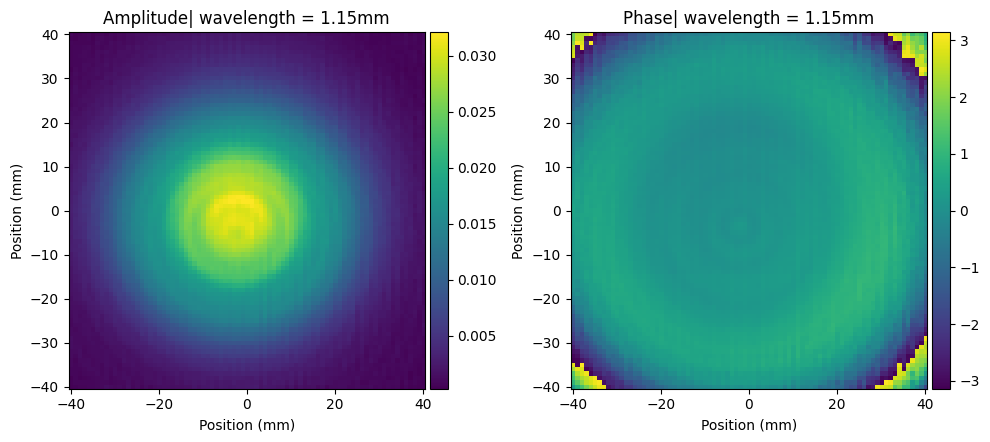

In [34]:
ApertureField.visualize(flag_axis = True, figsize=(10,10), wavelength=wavelengths[200], intensity=False)

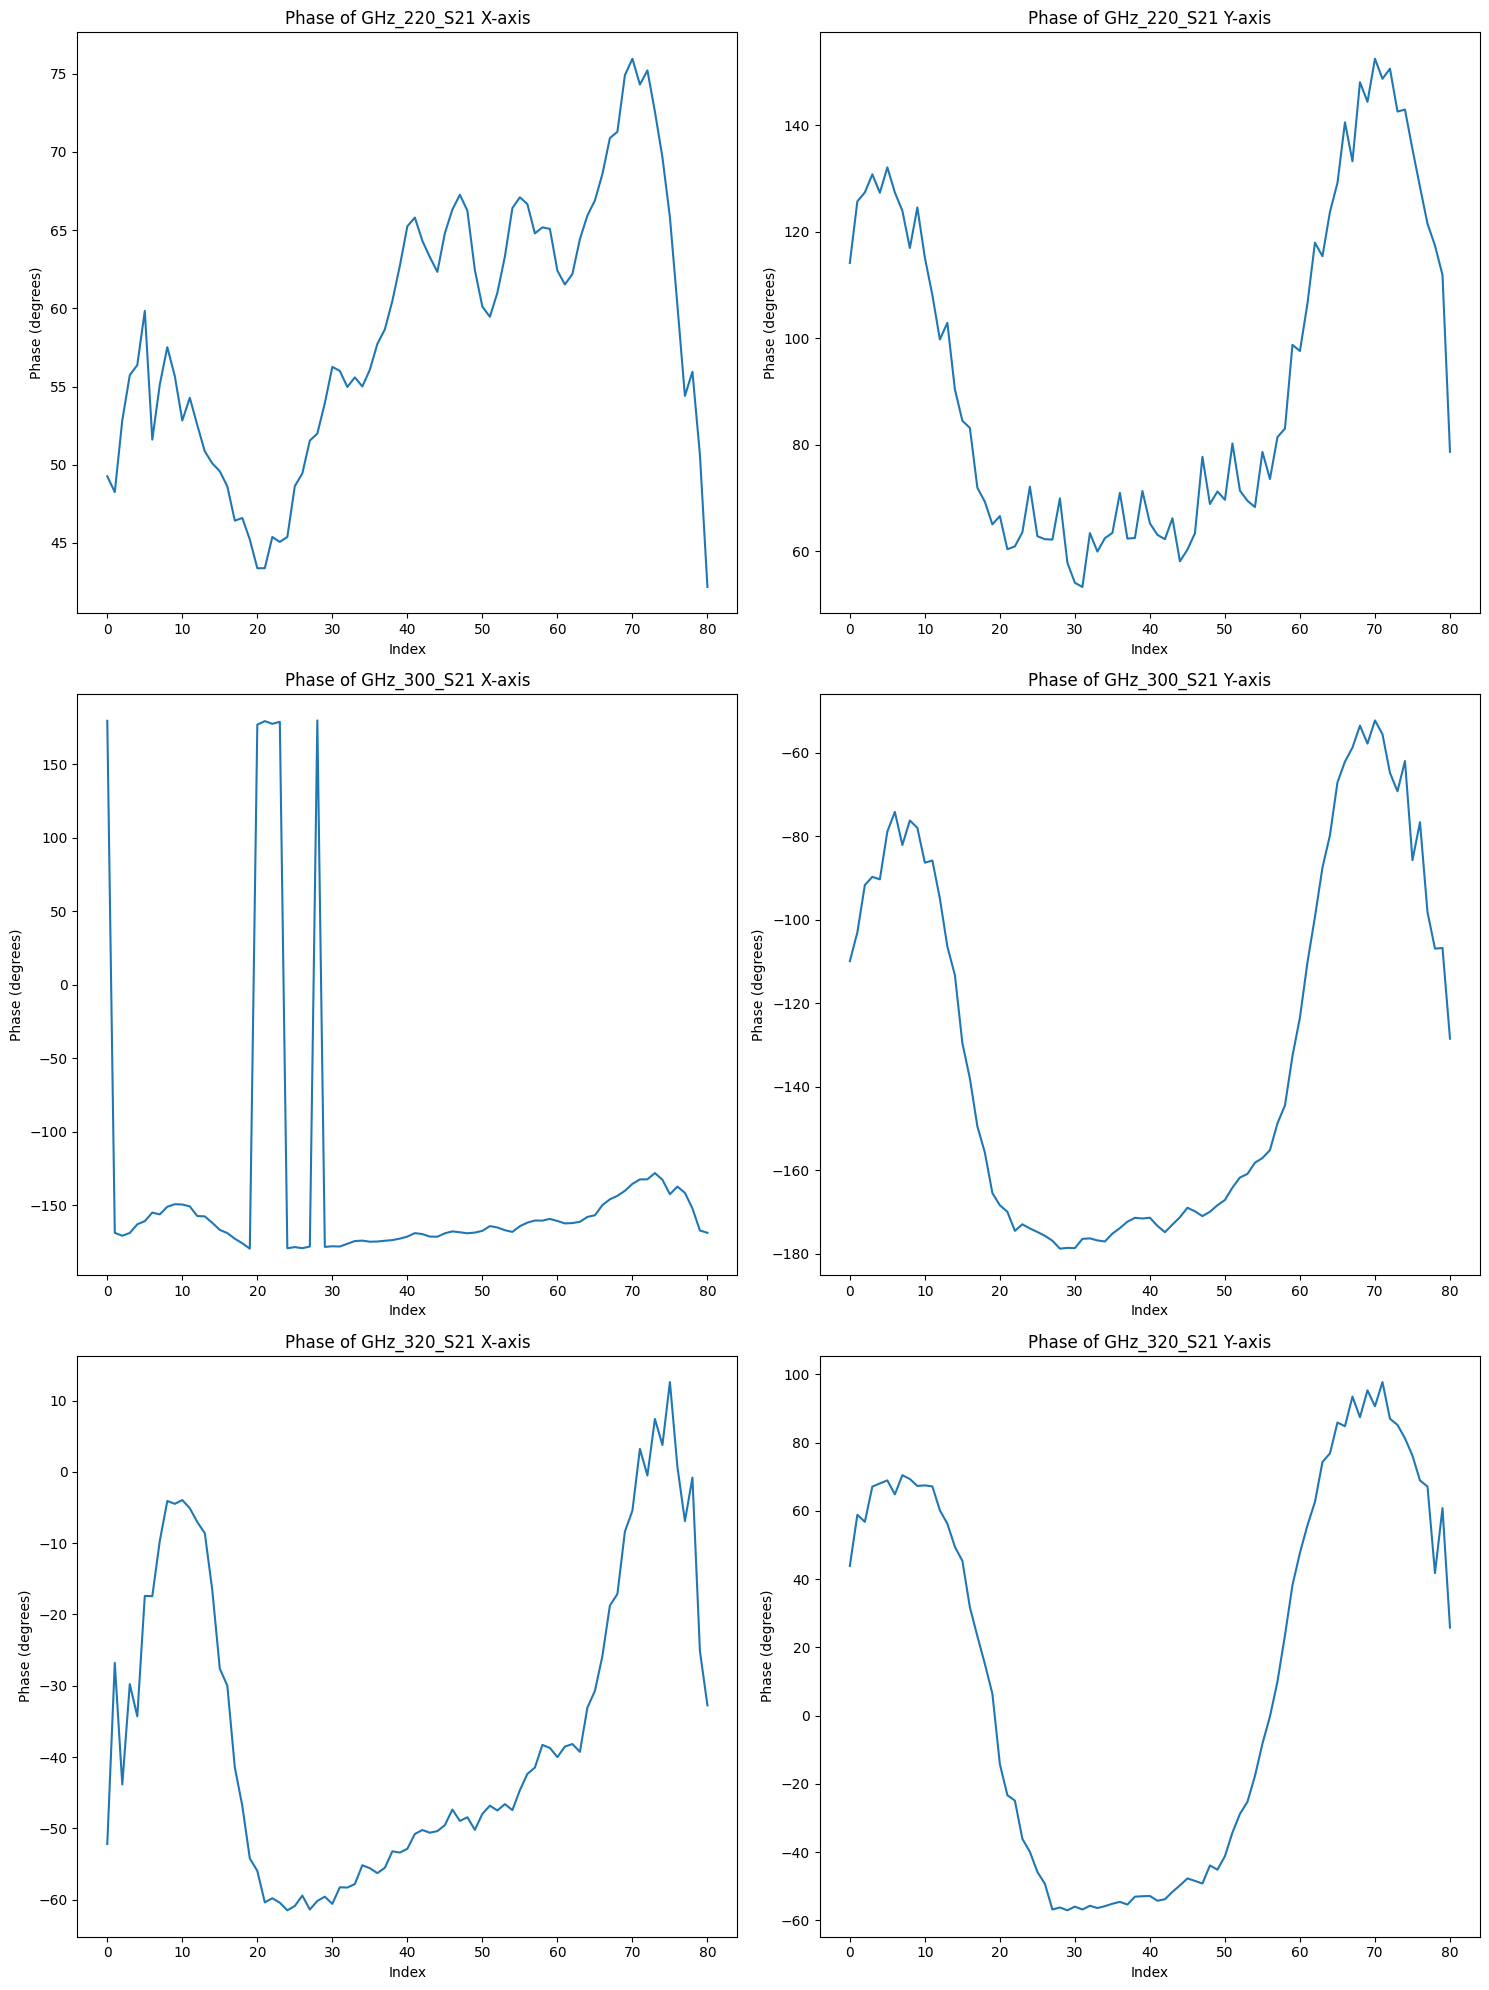

In [35]:
frequency[400]  # 0, 400, 500
GHz_220_S21 = s21[0, :, :]

GHz_300_S21 = s21[400, :, :]

GHz_320_S21 = s21[500, :, :]

import matplotlib.pyplot as plt

# Creating the plot
plt.figure(figsize=(15, 20))  # Optional: To set figure size

plt.subplot(3, 2, 1)  # Define the first subplot in a 1x2 grid
plt.plot(np.angle(GHz_220_S21[:, 40], deg=True))  # Plot phase in degrees for GHz_220_S21
plt.title('Phase of GHz_220_S21 X-axis')  # Optional: Adding a title for clarity
plt.xlabel('Index')  # Label for x-axis
plt.ylabel('Phase (degrees)')  # Label for y-axis

# You can add another plot if needed like so:
plt.subplot(3, 2, 2)  # Define the second subplot in a 1x2 grid
plt.plot(np.angle(GHz_220_S21[40, :], deg=True))  # Plot phase in degrees for GHz_300_S21
plt.title('Phase of GHz_220_S21 Y-axis')  # Optional: Adding a title for clarity
plt.xlabel('Index')  # Label for x-axis
plt.ylabel('Phase (degrees)')  # Label for y-axis

plt.subplot(3, 2, 3)  # Define the first subplot in a 1x2 grid
plt.plot(np.angle(GHz_300_S21[:, 40], deg=True))  # Plot phase in degrees for GHz_220_S21
plt.title('Phase of GHz_300_S21 X-axis')  # Optional: Adding a title for clarity
plt.xlabel('Index')  # Label for x-axis
plt.ylabel('Phase (degrees)')  # Label for y-axis

# You can add another plot if needed like so:
plt.subplot(3, 2, 4)  # Define the second subplot in a 1x2 grid
plt.plot(np.angle(GHz_300_S21[40, :], deg=True))  # Plot phase in degrees for GHz_300_S21
plt.title('Phase of GHz_300_S21 Y-axis')  # Optional: Adding a title for clarity
plt.xlabel('Index')  # Label for x-axis
plt.ylabel('Phase (degrees)')  # Label for y-axis

plt.subplot(3, 2, 5)  # Define the first subplot in a 1x2 grid
plt.plot(np.angle(GHz_320_S21[:, 40], deg=True))  # Plot phase in degrees for GHz_220_S21
plt.title('Phase of GHz_320_S21 X-axis')  # Optional: Adding a title for clarity
plt.xlabel('Index')  # Label for x-axis
plt.ylabel('Phase (degrees)')  # Label for y-axis

# You can add another plot if needed like so:
plt.subplot(3, 2, 6)  # Define the second subplot in a 1x2 grid
plt.plot(np.angle(GHz_320_S21[40, :], deg=True))  # Plot phase in degrees for GHz_300_S21
plt.title('Phase of GHz_320_S21 Y-axis')  # Optional: Adding a title for clarity
plt.xlabel('Index')  # Label for x-axis
plt.ylabel('Phase (degrees)')  # Label for y-axis

plt.tight_layout()  # Adjust the spacing between subplots for a better look
plt.show()

In [36]:
import numpy as np
from PIL import Image
from utils.Helper_Functions import normalize
import matplotlib.pyplot as plt
import torch.nn.functional as F
def define_FoM(resolution, sampling_size, wavelength, focal_length, position):
    """
    Calculates the Full-width-at-half-maximum (FWHM) by the far-field diffraction limit
    and applies it to model the point spread function (PSF) as a Gaussian function, with consistent intensity across positions.
    
    Parameters:
        resolution (tuple): The resolution of the field in pixels (height, width).
        sampling_size (float): The physical size of each pixel, in meters.
        wavelength (float): The wavelength of the light, in meters.
        focal_length (float): The focal length of the optical system, in meters.
        position (tuple): The target position in the field, in meters (x, y).
        
    Returns:
        torch.Tensor: The calculated and normalized PSF as a 2D Gaussian function over the specified field.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    height, width = resolution
    Length_x = sampling_size * width
    Length_y = sampling_size * height
    
    effective_L = torch.sqrt(torch.tensor((Length_x ** 2 + Length_y ** 2), device=device))
    NA = torch.sin(torch.atan(effective_L / (2 * focal_length)))
    FWHM = wavelength / (2 * NA)
    
    x_grid, y_grid = torch.meshgrid(torch.linspace(-Length_x / 2, Length_x / 2, steps=width, device=device),
                                    torch.linspace(-Length_y / 2, Length_y / 2, steps=height, device=device))
    
    x_position, y_position = torch.tensor(position, device=device)
    
    # Calculate the Gaussian PSF
    PSF = torch.exp(-((x_grid - x_position) ** 2 + (y_grid - y_position) ** 2) / ((FWHM*2) ** 2))
    
    # Normalize the PSF such that its maximum value is 1
    
    return normalize(PSF.unsqueeze(0).unsqueeze(0))

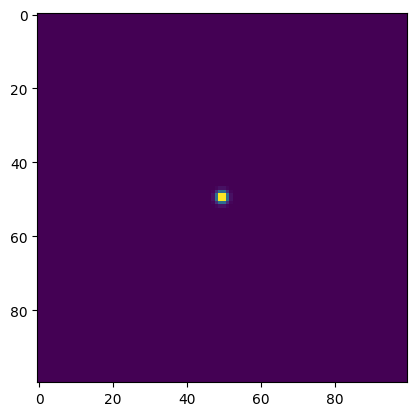

In [37]:
PSF_1 = define_FoM(resolution=input_field_shape, sampling_size=input_dxy, 
                  wavelength=wavelength, focal_length=70*mm, position=[0*mm, 0*mm])

target = PSF_1
plt.imshow(target[0, 0, :, :].cpu())

In [38]:
class Setup(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 measured_input_field_data,
                 input_dxy, 
                 input_field_shape,
                 doe_data,
                 doe_params, 
                 wavelengths, 
                 device='cuda:0'):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        self.device = device
        self.wavelengths = wavelengths

        # measured plane wave
        self.source = ElectricField(data=measured_input_field_data, 
                                    wavelengths=self.wavelengths, 
                                    spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        self.doe = FixDOEElement(height_map=doe_data, 
                                 tolerance=0*mm, 
                                 material=self.doe_params['material'])
        
        
        self.asm_prop1 = ASM_prop(z_distance=52 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)

    
    def forward(self, z):
        input_field = self.source
        
        field = self.aperture(self.doe(input_field))

        self.asm_prop1.z = z
        final_field = self.asm_prop1(field)
        
        return final_field

class Submm_Setup_test(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 measured_input_field_data,
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 wavelengths, 
                 doe_data):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        
        self.wavelengths = wavelengths

        # measured plane wave
        self.source = ElectricField(data=measured_input_field_data, 
                                    wavelengths=self.wavelengths, 
                                    spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        self.doe = FixDOEElement(height_map=doe_data, 
                                 tolerance=0*mm, 
                                 material=self.doe_params['material'])
        
        self.prop_range = np.linspace(1*mm, 100*mm, num=200)
        self.asm_prop3 = ASM_prop(z_distance=1 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)
    
    def forward(self):
        fields_zx = []
        input_field = self.source
        field = self.aperture(self.doe(input_field))
        final_field = self.asm_prop3(field)

        #field_data = final_field.data[0, 0, 49, :]
        #print(field_data.shape)
        #fields_zx.append(field_data)  # Use parentheses here
        
        for z in self.prop_range:
            self.asm_prop3.z = z
            final_field = self.asm_prop3(field)
            field_data = final_field.data[0, 0, 49, :]
            fields_zx.append(field_data)  # Use parentheses here

        stacked_fields_zx = torch.stack(fields_zx)
        
        return stacked_fields_zx

In [52]:
data = np.load('./plot_data/experiment_prototypes/height_map_hologram_1mm.npy', allow_pickle=True)

dxy = data.item().get('dxy')
doe_data = data.item().get('thickness')
pad_value = int(10 / (dxy / mm))

doe_data = np.pad(doe_data, ((pad_value, pad_value), (pad_value, pad_value)), mode='constant', constant_values=0)
print(doe_data.shape)
doe_params['dxy'] = dxy

setup = Setup(measured_input_field_data=ApertureField300GHz,
            input_dxy=input_dxy, 
            input_field_shape=input_field_shape, 
            doe_data=doe_data,
            doe_params=doe_params, 
            wavelengths=wavelength)

(100, 100)


The critical distance is [0.4333979] m, the TF will be fine during the sampling !


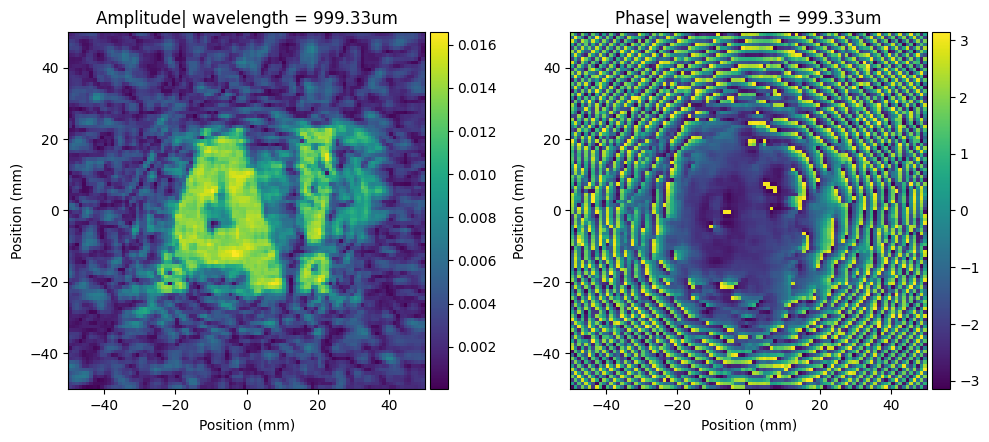

In [53]:
field = setup.forward(z=100 * mm)

field.visualize(flag_axis = True, figsize=(10,10), wavelength=wavelength, intensity=False)

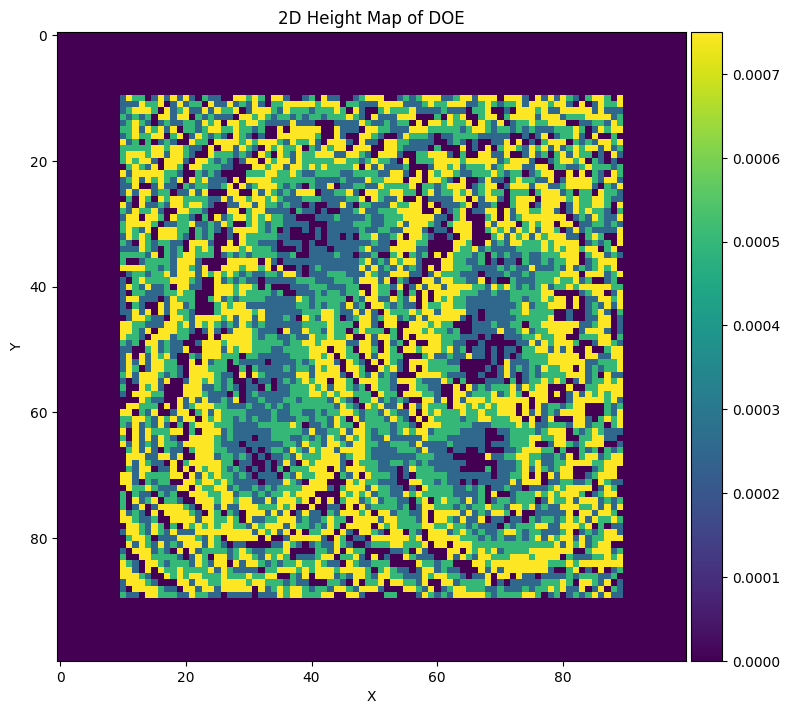

In [54]:
setup.doe.visualize(figsize=(8,8))

In [55]:
setup_test = Submm_Setup_test(measured_input_field_data = ApertureField300GHz,
                              input_dxy=input_dxy, 
                              input_field_shape=input_field_shape,
                              doe_params=doe_params, 
                              wavelengths=wavelengths, 
                              doe_data=doe_data)

data = setup_test.forward()
data = data.cpu().abs()**2

ValueError: The number of channels in data should be equal to the number of wavelengths

In [ ]:
plt.imshow(data.detach().numpy())

## Loss landscape

In [ ]:
class Args:
    def __init__(self):
        self.save_path = 'loss_landscape_results'  # Base path for saving loss landscape images
        self.ex_name = 'splitter_full'  # Type of Experiments
        self.xmin = -6    # Minimum value of x-coordinate
        self.xmax = 6     # Maximum value of x-coordinate
        self.xnum = 801    # Number of x-coordinate
        self.ymin = -6    # Minimum value of y-coordinate
        self.ymax = 6     # Maximum value of y-coordinate
        self.ynum = 801    # Number of y-coordinate
        self.save_imges = True
        self.surf_name = 'loss'    # The type of surface to plot
        self.vmin = 0.01        # Miminum value to map
        self.vmax = 1        # Maximum value to map
        self.vlevel = 0.1      # plot contours every vlevel

# Instantiate and use the Args class
args = Args()

save_path = os.path.join(args.save_path, args.ex_name) 
if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [ ]:
from VisTools.directions import create_random_directions
from VisTools.calc_loss import calulate_single_element_loss_landscape
from VisTools.visualize import visualize_notebook

In [ ]:
rand_directions = create_random_directions(best_setup)
surface_path = calulate_single_element_loss_landscape(args, model=setup, target=target, loss_f=photometric_loss_fn, directions=rand_directions, save_path=save_path)
visualize_notebook(args, save_path, surface_path)

In [ ]:
class Submm_Setup_test(nn.Module):
    """ simulate a simple system with one diffractive optical element 
        (Original Gumbel Quantized method with annealing factor)
    """
    def __init__(self, 
                 input_dxy, 
                 input_field_shape,
                 doe_params, 
                 wavelengths, 
                 doe_data):
        super().__init__()
        
        self.input_dxy = input_dxy
        self.input_field_shape = input_field_shape
        self.doe_params = doe_params
        
        self.wavelengths = wavelengths

        # Here we use the fit funtion of BeamWaistCorruagtedTK 
        self.source = PlaneWave(height=self.input_field_shape[0], 
                                width=self.input_field_shape[1], 
                                wavelengths=self.wavelengths, 
                                spacing=self.input_dxy)
        
        self.aperture = ApertureElement(aperture_type = 'rect',
                                   aperture_size = 0.08)

        self.doe = FixDOEElement(height_map=doe_data, 
                                 tolerance=0*mm, 
                                 material=self.doe_params['material'])
        
        self.prop_range = np.linspace(20*mm, 90*mm, num=200)
        self.asm_prop3 = ASM_prop(z_distance=20 * mm, 
                         bandlimit_type='exact', 
                         padding_scale=4, 
                         bandlimit_kernel=True)
    
    def forward(self):
        fields_zx = []
        input_field = self.source()
        field = self.doe(input_field)
        final_field = self.asm_prop3(field)

        #field_data = final_field.data[0, 0, 49, :]
        #print(field_data.shape)
        #fields_zx.append(field_data)  # Use parentheses here
        
        for z in self.prop_range:
            self.asm_prop3.z = z
            final_field = self.asm_prop3(field)
            field_data = final_field.data[0, 0, 49, :]
            fields_zx.append(field_data)  # Use parentheses here

        stacked_fields_zx = torch.stack(fields_zx)
        
        return stacked_fields_zx

In [ ]:
#doe_data = best_setup.doe.height_map

doe_data = np.load('./FDTDval/data/edof_4levels.npy', allow_pickle=True)
doe_data = doe_data.item().get('thickness')
pad_width = ((10, 10), (10, 10))  # (top/bottom, left/right)
doe_data = np.pad(doe_data, pad_width, mode='constant', constant_values=0)  # Pad with zeros


setup_test = Submm_Setup_test(input_dxy=input_dxy, 
                              input_field_shape=input_field_shape, 
                              doe_params=doe_params, 
                              wavelengths=wavelengths, 
                              doe_data=doe_data)

data = setup_test.forward()

data = data.cpu().abs()**2


plt.imshow(data.detach().numpy())

In [ ]:
plt.plot(data[:, 49].detach().numpy())

In [ ]:
setup_test.doe.visualize(figsize=(8,8))

## Loss landscape

In [ ]:
from VisTools.directions import create_random_directions
from VisTools.calc_loss import calulate_single_element_loss_landscape
from VisTools.visualize import visualize_notebook

class Args:
    def __init__(self):
        self.save_path = 'loss_landscape_results'  # Base path for saving loss landscape images
        self.ex_name = 'splitter_full'  # Type of Experiments
        self.xmin = -8    # Minimum value of x-coordinate
        self.xmax = 8     # Maximum value of x-coordinate
        self.xnum = 801    # Number of x-coordinate
        self.ymin = -8    # Minimum value of y-coordinate
        self.ymax = 8     # Maximum value of y-coordinate
        self.ynum = 801    # Number of y-coordinate
        self.save_imges = True
        self.surf_name = 'loss'    # The type of surface to plot
        self.vmin = 0.01        # Miminum value to map
        self.vmax = 1        # Maximum value to map
        self.vlevel = 0.1      # plot contours every vlevel

# Instantiate and use the Args class
args = Args()

save_path = os.path.join(args.save_path, args.ex_name) 
if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [ ]:
rand_directions = create_random_directions(best_setup)
surface_path = calulate_single_element_loss_landscape(args, model=setup, target=target, loss_f=photometric_loss_fn, directions=rand_directions, save_path=save_path)
visualize_notebook(args, save_path, surface_path)

In [ ]:
#best_setup.doe.save(crop_size=[80, 80])